# Population Geography and Demographic Analysis with Python

**Coursework language:** Macedonian

This notebook is a public portfolio version of a 2022 interdisciplinary Bachelor coursework project. It preserves the original exploratory methodology and visualizations. The source tables contain historical formatting and transcription inconsistencies, and the regression experiments should be interpreted as introductory coursework rather than authoritative demographic forecasting.


In [ ]:
# Читање на потребните податочни множества
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path("data")

data1 = pd.read_csv(DATA_DIR / "annual_birth_rate.csv")
data2 = pd.read_csv(DATA_DIR / "natural_increase.csv")
data3 = pd.read_csv(DATA_DIR / "natural_increase_by_ethnicity.csv")
data4 = pd.read_csv(DATA_DIR / "age_structure.csv")
data5 = pd.read_csv(DATA_DIR / "ethnic_structure.csv")
data6 = pd.read_csv(DATA_DIR / "urban_rural_population.csv")


In [ ]:
#Godisen natalitet vo RM vo periodi
data1

,Период,Население во илјади,Просечно живородени годишно,На 1000 жители
0,1935-1939,1.039,36.208,34.9
1,1947-1951,1.195,45.803,38.3
2,1952-1956,1.328,49.656,37.4
3,1957-1961,1.382,44.321,32.1
4,1962-1966,1.479,41.733,28.2
5,1967-1971,1.605,39.399,24.6
6,1972-1976,1.729,38.687,22.3
7,1977-1981,1.862,39.280,21.1
8,1982-1986,1.955,38.963,19.6
9,1987-1991,2.017,36.522,17.5


In [ ]:
data1 = data1.loc[:, ~data1.columns.str.contains('^Unnamed')]

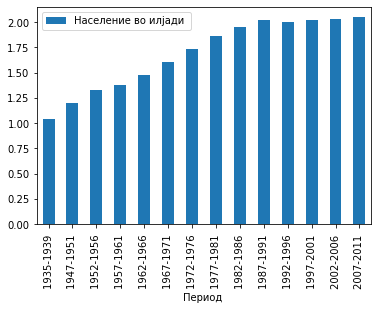

In [ ]:
data1.plot.bar(x=0,y=1) 

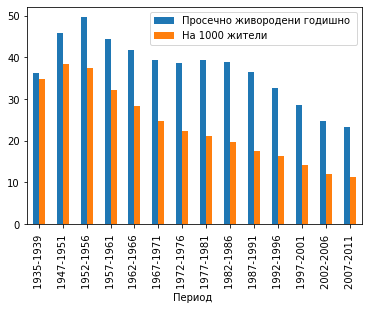

In [ ]:
data1.plot.bar(x=0, y=[2,3])

In [ ]:
#natalitetot e vo postojan pad, a srednite vrednosti se sledni za tabelata:
data1.median()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  


Население во илјади              1.7955
Просечно живородени годишно     38.8250
На 1000 жители                  21.7000
dtype: float64

In [ ]:
#4te kvantili na prirodniot prirast
data1.quantile([.1, .25, .5, .75], axis = 0)

,Население во илјади,Просечно живородени годишно,На 1000 жители
0.10,1.23490,25.78870,12.700
0.25,1.40625,33.45025,16.525
0.50,1.79550,38.82500,21.700
0.75,2.01275,41.14950,31.125


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt 

<Figure size 432x288 with 0 Axes>

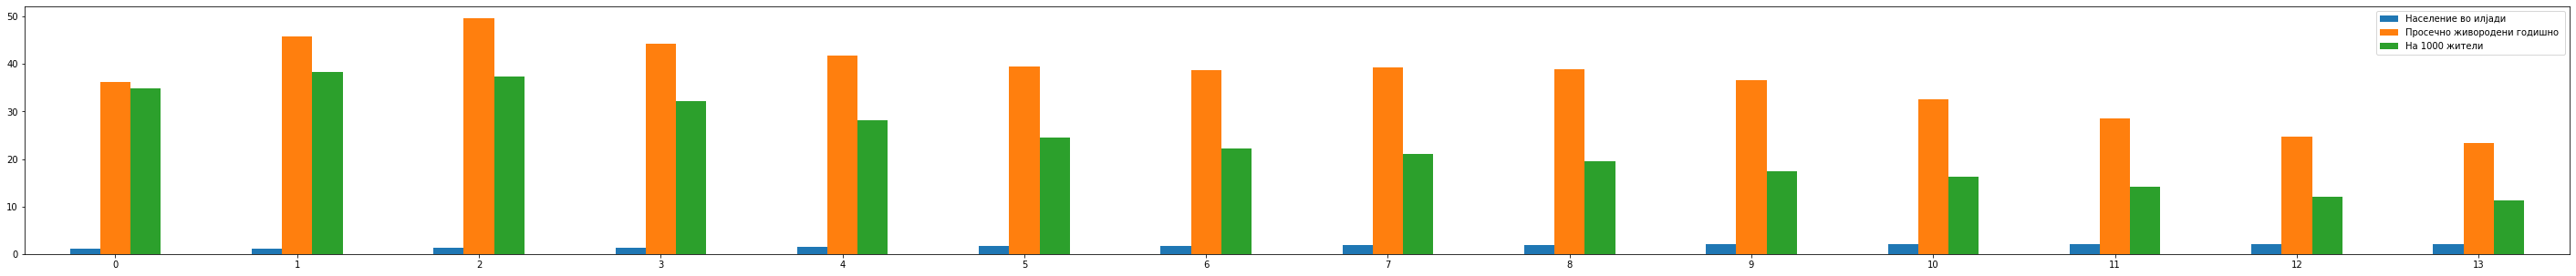

In [ ]:
fig = plt.figure()
data1.plot.bar(rot=0,figsize=(50,5))
fig.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 <a list of 14 Text major ticklabel objects>)

<Figure size 432x288 with 0 Axes>

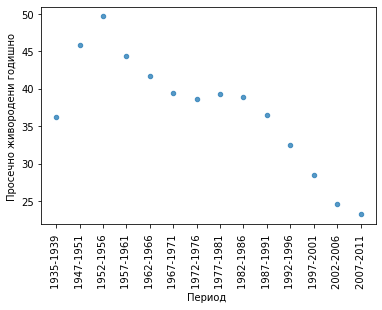

In [ ]:
#figura na prosecno zivorodeni godisno po period, povtorno se zabelezuva maksimumot
fig = plt.figure()
data1.plot.scatter(x= 0, y = 2, alpha = 0.75,rot=0)
plt.xticks(rotation=90)

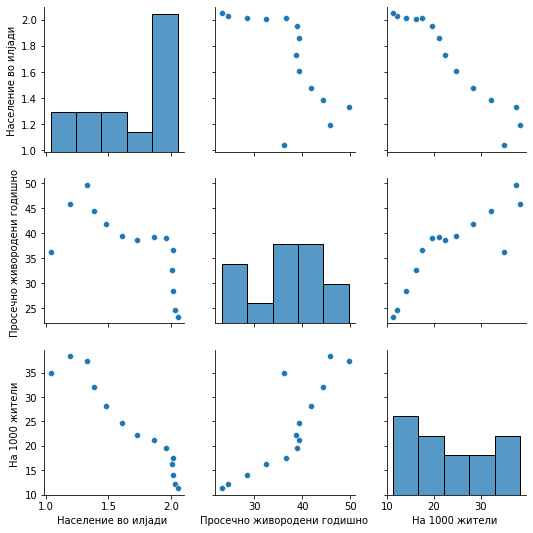

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#da vidime koi podatoci ni se vo kolinearna vrska
sns.pairplot(data1)

In [ ]:
print(data1.columns.tolist())

['Период ', 'Население во илјади ', 'Просечно живородени годишно ', 'На 1000 жители ']


In [ ]:
from sklearn.model_selection import train_test_split

X = data1.iloc[:,[1]].values
Y = data1.iloc[:,[3]].values
X_train, X_test, Y_train, Y_test = train_test_split(
    data1.iloc[:,[1]].values, data1.iloc[:,[3]].values, test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
Y_train=scaler.fit_transform(Y_train)
Y_test=scaler.fit_transform(Y_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error 


poly_reg = PolynomialFeatures(4)

X_poly = poly_reg.fit_transform(X_train)

poly_reg.fit(X_poly, Y_train)

#kreirame objekt od klasata LinearRegression
lin_reg = LinearRegression()

#go sovpagjame
lin_reg.fit(X_poly, Y_train)

X_test_poly = poly_reg.fit_transform(X_test)
y_pred=lin_reg.predict(X_test_poly)
test_score=mean_squared_error (Y_train,lin_reg.predict(X_poly))
training_score=mean_squared_error(Y_test,y_pred)

print("MSE za testing data: " + str(test_score))
print("MSE za training data: " +  str(training_score))

MSE za testing data: 0.007010548129130439
MSE za training data: 0.2608006576767507


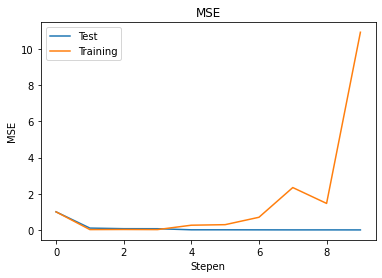

In [ ]:
#Dobivame sredna kvadratna greska mnogu bliska do 0, shto znachi modelot ni e soliden 
#sporedbata se pravi na test i training podeleni podatocni mnozestva koi se: naselenie vo iljadi / zivorodeni godisno i zivorodeni na 1000 ziteli
train = []
test = []
for i in range(0,10):
    poly=PolynomialFeatures(degree=i, )
    X_poly=poly.fit_transform(X_train)
    l=LinearRegression()
    l.fit(X_poly,Y_train)
    
    X_test_poly =poly.fit_transform(X_test)
    y_pred=l.predict(X_test_poly)
    training_score=mean_squared_error (Y_train,l.predict(X_poly))
    test_score=mean_squared_error(Y_test,y_pred)
    train.append(training_score)
    test.append(test_score)

x=np.arange(10)
plt.plot(x,train,label="Test")
plt.plot(x,test,label="Training")
plt.legend()
plt.xlabel("Stepen")
plt.ylabel("MSE")
plt.title("MSE");
plt.show()

In [ ]:
#MSE raste za podatocno mnozestvo so naselenie vo iljadi i zivorodeni godisno
#MSE za podatocno mnozestvo so zivorodeni godisno i na 1000 ziteli se priblizuva kon 0, shto znachi otprilika isto bi prodolzile da opagjaat vo idnina


In [ ]:
data2

,Природен прираст во период,вкупно,на 1000 жители
0,1935-39,16.186,15.6
1,1947-51,27.761,23.2
2,1952-56,32.191,24.3
3,1957-61,29.640,21.5
4,1962-66,28.186,19.1
5,1967-71,26.804,16.7
6,1972-76,26.195,15.1
7,1977-81,26.269,14.1
8,1982-86,24.801,12.5
9,1987-91,21.875,10.5


In [ ]:
print(data2.columns.tolist())

['Природен прираст во период ', 'вкупно ', 'на 1000 жители ']


In [ ]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 3 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Природен прираст во период   11 non-null     object 
 1   вкупно                       11 non-null     float64
 2   на 1000 жители               11 non-null     float64
dtypes: float64(2), object(1)
memory usage: 392.0+ bytes


In [ ]:
data2.median()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


вкупно             26.269
на 1000 жители     15.600
dtype: float64

In [ ]:
#najgolem priroden prirast vo daden period
data2['вкупно '].max()

32.191

<Figure size 432x288 with 0 Axes>

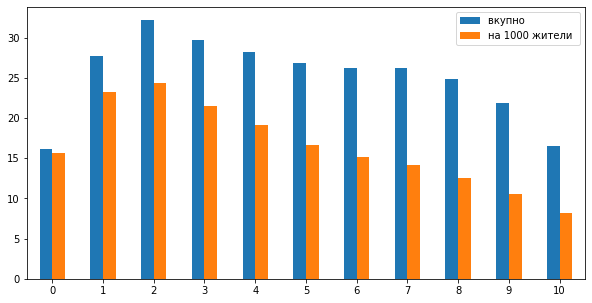

In [ ]:
fig = plt.figure()
data2.plot.bar(rot=0,figsize=(10,5))
fig.show()

In [ ]:
data2.head()

,Природен прираст во период,вкупно,на 1000 жители
0,1935-39,16.186,15.6
1,1947-51,27.761,23.2
2,1952-56,32.191,24.3
3,1957-61,29.640,21.5
4,1962-66,28.186,19.1


In [ ]:
#ja isfrlame prvata kolona za da rabotime so decimalni broevi samo
data2 = data2.drop(columns=['Природен прираст во период '])

In [ ]:
data2

,вкупно,на 1000 жители
0,16.186,15.6
1,27.761,23.2
2,32.191,24.3
3,29.640,21.5
4,28.186,19.1
5,26.804,16.7
6,26.195,15.1
7,26.269,14.1
8,24.801,12.5
9,21.875,10.5


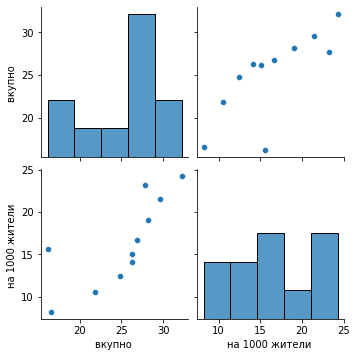

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


sns.pairplot(data2)

In [ ]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, Y_train2, Y_test2 = train_test_split(
    data2.iloc[:,[0,1]].values, data2.iloc[:,[0,1]].values, test_size=0.5)

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Kreirame Decision Tree regressor objekt

regressor = DecisionTreeRegressor()

# Go trenirame regresorot
regressor.fit(X_train2, Y_train2)

#go procenuvame odgovorot na test podatocnoto mnozestvo
y_pred = regressor.predict(X_test2)

In [ ]:
print("Прецизноста изнесува: ",regressor.score(X_test2, Y_test2))

Прецизноста изнесува:  0.3669301729107128


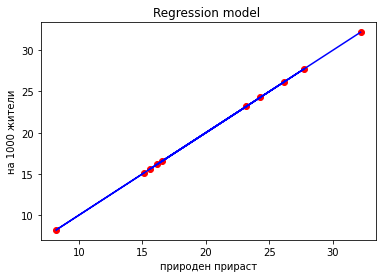

In [ ]:
plt.scatter(X_train2, Y_train2, color = 'red')
plt.plot(X_train2, regressor.predict(X_train2), color = 'blue')
plt.title('Regression model ')
plt.xlabel('природен прираст')
plt.ylabel('на 1000 жители')
plt.show()

In [ ]:
data3

,Период,Природен прираст,Македонци,Албанци,Турци,Роми,Останати
0,1662-66,28188,15431,6458,3000,816,2484
1,1967-71,26804,13959,7937,2371,821,1718
2,1972-76,26195,13209,8181,2185,941,1680
3,1977-81,26269,13370,8336,1977,1176,1411
4,1982-86,24801,12299,8312,1458,1401,1330
5,1987-91,21875,9031,8836,1546,1334,1128
6,1992-96,16574,4619,9086,1116,1043,710


In [ ]:
data3.median()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  """Entry point for launching an IPython kernel.


Природен прираст     26195.0
Македонци            13209.0
Албанци               8312.0
Турци                 1977.0
Роми                  1043.0
Останати              1411.0
dtype: float64

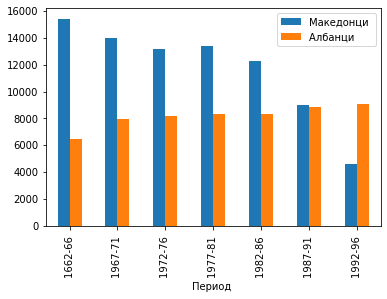

In [ ]:
data3.plot.bar(x=0, y=[2,3])

<Figure size 432x288 with 0 Axes>

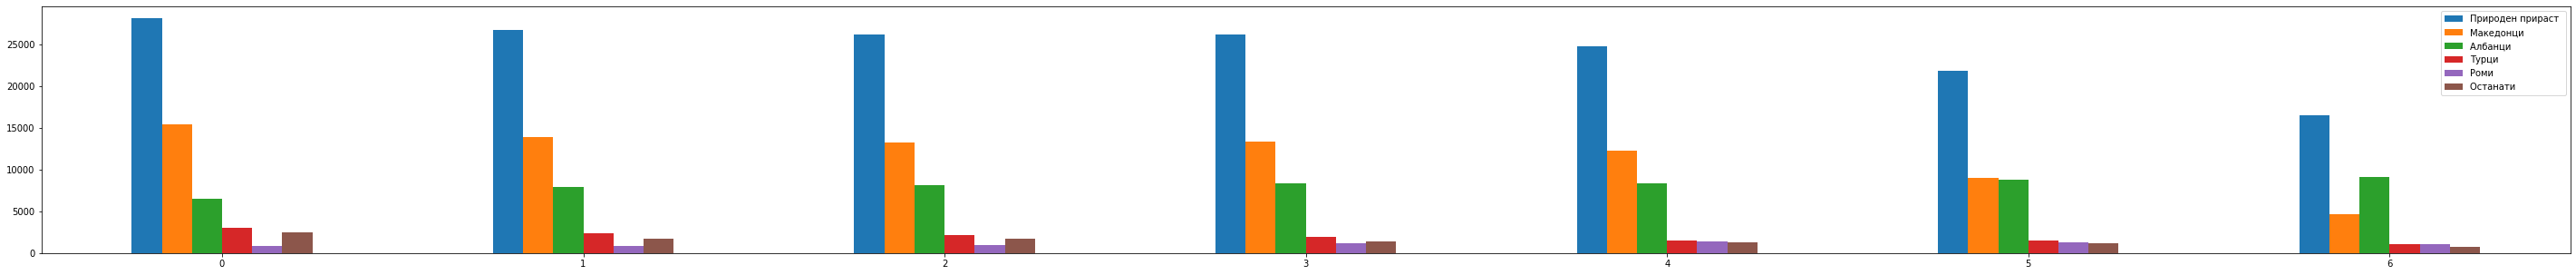

In [ ]:
fig = plt.figure()
data3.plot.bar(rot=0,figsize=(50,5))
fig.show()

In [ ]:
#ja isfrlame prvata kolona so cel podobra vizuelizacija
data3 = data3.drop(columns='Природен прираст ')

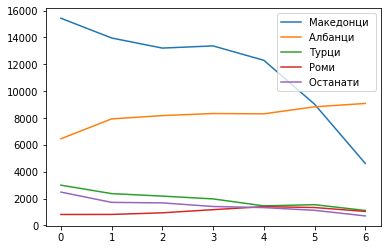

In [ ]:
data3.plot()

In [ ]:
data4

,Попис,Вкупно,0-14 г.,%,15-64 г.,% .1,65>,% .2,непознато
0,1921,797841,713773,"39,4",426653,"53,4",57444,"7,2",-
1,1931,949958,364277,"38,3",526798,"54,5",58853,"7,2",30
2,1948,1.152.986,437986,"38,0",643313,"55,8",71635,"6,2",52
3,1953,1.304.514,481713,"36,9",745535,"57,2",77127,"5,9",139
4,1961,1.406.003,522919,"37,2",806761,"57,5",74891,"5,3",1432
5,1971,1.647.308,535713,"32,5",1.012.359,"61,5",94859,"6,0",4377
6,1981,1.909.136,555177,"29,1",1.221.155,"64,0",128261,"6,9",4543
7,1991,2.033.964,487952,"24,0",1.365.390,"67,2",165716,"8,1",14906
8,1994,1.945.932,483923,"24,9",1.294.028,"66,5",164678,"8,5",3303
9,2002,2.022.547,428039,"21,2",1.381.388,"68,3",213712,"10,5",1203


In [ ]:
print(data4.columns.tolist())

['Попис ', 'Вкупно ', '0-14 г. ', '% ', '15-64 г. ', '% .1', '65> ', '% .2', 'непознато ']


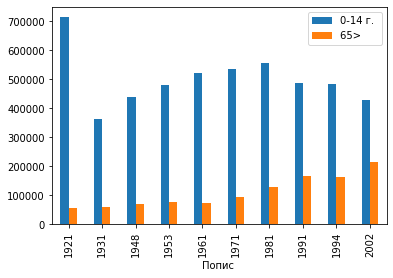

In [ ]:
#gresno go cita podatokot za naselenie vo 2002 od 0-14g starost, isto taka ne ja vcituva kolonata za starost od 15 do 64g
data4.plot.bar(x=0, y=['0-14 г. ', '15-64 г. ', '65> '])

In [ ]:
#se voocuva deka brojkata na novorodencinja i decata do 14 godini se namaluva, a brojkata na stari lica se zgolemuva
data4 = data4.drop(columns='Попис ')
data4.plot()

In [ ]:
data5

,Националност 1900г.,Unnamed: 1,1921г.,1948г.,1953г.,1961г.,1971г.,1981г.,1991г.,1994г.,2002г.
0,Македонци,534000,540000,789648.0,860699,1000854,11142375.0,1279323.0,1328187.0,1378687.0,1297981
1,Албанци,88000,111000,197389.0,162524,183108,279871.0,377208.0,441987.0,478967.0,509083
2,Турци,175000,119000,959940.0,NaN,NaN,108552.0,86591.0,77080.0,81615.0,77959
3,Роми,20000,7800,19500.0,20462,20608,24505.0,43125.0,52103.0,47408.0,53879
4,Срби,///,///,29721.0,35112,42728,46465.0,44468.0,42775.0,39866.0,35939
5,Власи,30000,9000,9511.0,8668,8046,7190.0,6384.0,7764.0,8574.0,9695
6,Останати,62000,11041,11277.0,13111,19180,38350.0,72073.0,84086.0,40079.0,38011
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Page1


In [ ]:
#razrabotka/preprocessing
data5=data5.dropna()

In [ ]:
print(data5.columns.tolist())

['Националност 1900г. ', 'Unnamed: 1', '1921г. ', '1948г. ', '1953г. ', '1961г. ', '1971г. ', '1981г. ', '1991г. ', '1994г. ', '2002г. ']


In [ ]:
data5 = data5.drop(columns='Unnamed: 1')


In [ ]:
data5.rename(columns = {'Националност 1900г. ':'Националност'}, inplace = True)

In [ ]:

data5

,Националност,1921г.,1948г.,1953г.,1961г.,1971г.,1981г.,1991г.,1994г.,2002г.
0,Македонци,540000,789648.0,860699,1000854,11142375.0,1279323.0,1328187.0,1378687.0,1297981
1,Албанци,111000,197389.0,162524,183108,279871.0,377208.0,441987.0,478967.0,509083
2,Турци,119000,959940.0,NaN,NaN,108552.0,86591.0,77080.0,81615.0,77959
3,Роми,7800,19500.0,20462,20608,24505.0,43125.0,52103.0,47408.0,53879
4,Срби,///,29721.0,35112,42728,46465.0,44468.0,42775.0,39866.0,35939
5,Власи,9000,9511.0,8668,8046,7190.0,6384.0,7764.0,8574.0,9695
6,Останати,11041,11277.0,13111,19180,38350.0,72073.0,84086.0,40079.0,38011


In [ ]:
#etnicka struktura
print(data5.columns.tolist())

['Националност', '1921г. ', '1948г. ', '1953г. ', '1961г. ', '1971г. ', '1981г. ', '1991г. ', '1994г. ', '2002г. ']


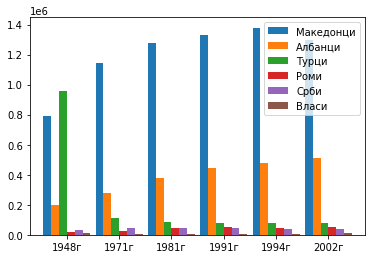

In [ ]:
makedonci = [789648.0, 1142375.0, 	1279323.0, 1328187.0, 1378687.0, 1297981]
albanci = [197389.0, 279871.0, 377208.0, 441987.0, 478967.0, 509083]
turci = [959940.0, 108552.0, 86591.0, 77080.0, 81615.0, 77959]
romi = [19500.0, 24505.0, 43125.0, 52103.0, 47408.0, 53879]
srbi = [29721.0, 46465.0, 44468.0, 42775.0, 39866.0, 35939]
vlasi = [9511.0, 7190.0, 6384.0, 7764.0, 8574.0, 9695]


index = ['1948г', '1971г', '1981г',
         '1991г', '1994г', '2002г']
data5 = pd.DataFrame({'Македонци': makedonci,
                   'Албанци': albanci, 'Турци': turci, 'Роми': romi, 'Срби' : srbi, 'Власи' : vlasi}, index=index)
ax = data5.plot.bar(rot=0, width=0.9)

In [ ]:
data6



,Godina na popisot,Selsko naselenie %,Gradsko naselenie %
0,1948,71.3,28.7
1,1953,68.7,31.3
2,1961,61.4,38.6
3,1971,51.2,48.8
4,1981,44.8,55.2
5,1994,40.2,59.8


In [ ]:
print(data6.columns.tolist())
        

['Godina na popisot ', 'Selsko naselenie % ', 'Gradsko naselenie % ']


In [ ]:
index = ['1948', '1953', '1961',
         '1971', '1981', '1994']
data6 = data6.drop(columns='Godina na popisot ')

In [ ]:
#selsko nasproti gradsko naselenie
data6

,Selsko naselenie %,Gradsko naselenie %
0,71.3,28.7
1,68.7,31.3
2,61.4,38.6
3,51.2,48.8
4,44.8,55.2
5,40.2,59.8


In [ ]:
selsko = [71.3, 68.7, 61.4, 51.2, 44.8, 40.2]
gradsko = [28.7, 31.3, 38.6, 48.8, 55.2, 59.8]
data6 = pd.DataFrame({'Selsko naselenie %': selsko,
                   'Gradsko naselenie %': gradsko}, index=index)


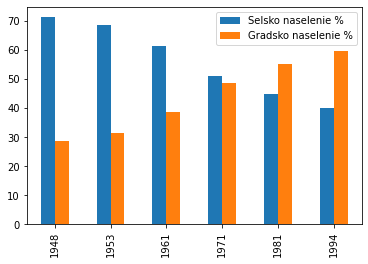

In [ ]:
data6.plot.bar()